In [2]:
import os
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from lib import PairedDataset, collate_paired_sequences
from lib import Trainer
from lib import FullyConnectedEmbed, ContactCNN, ModelInteraction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
spe = "yeast"

# data_dir = "data"
data_dir = "drive/MyDrive/ppi-data"

# Embedding model
input_dim = 13 # dimension of input embedding (d0)
projection_dim = 13 # dimension of embedding projection layer (d)
dropout_p = 0.5 # parameter p for embedding dropout layer

# Contact model
hidden_dim = 3 # number of hidden units for comparison layer in contact prediction (h)
kernel_width = 7 # width of convolutional filter for contact prediction
pool_width = 9 # size of max-pool in interaction model

# ModelInteraction model
do_w = False
do_pool = False
do_sigmoid = True

# Training
num_epochs = 10 # number of epochs
weight_decay = 0 # L2 regularization
lr = 0.001 # learning rate
interaction_weight = 0.35 # weight on the similarity objective
batch_size = 1


In [4]:
train_file = os.path.join(data_dir, spe, "action/train_action.tsv")
val_file = os.path.join(data_dir, spe, "action/test_action.tsv")
embedding_h5 = os.path.join(data_dir, spe, "seq/protein.embedding.h5")

train_df = pd.read_csv(train_file, sep="\t", header=None)
train_dataset = PairedDataset(train_df[0].to_list(), train_df[1].to_list(),
                              train_df[2].to_list(), embedding_h5)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=collate_paired_sequences,
    shuffle=True,
)

val_df = pd.read_csv(val_file, sep="\t", header=None)
val_dataset = PairedDataset(val_df[0].to_list(), val_df[1].to_list(),
                              val_df[2].to_list(), embedding_h5)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=collate_paired_sequences
)

In [5]:
# Create embedding model
embedding_model = FullyConnectedEmbed(
    input_dim, projection_dim, dropout=dropout_p
)

# Create contact model
contact_model = ContactCNN(projection_dim, hidden_dim, kernel_width)

# Create the full model
model = ModelInteraction(
    embedding_model,
    contact_model,
    do_w=do_w,
    pool_size=pool_width,
    do_pool=do_pool,
    do_sigmoid=do_sigmoid
)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params, lr=lr, weight_decay=weight_decay)
loss_fn = nn.BCELoss()

tainer = Trainer(model, loss_fn, optimizer)
tainer.set_loaders(train_loader, val_loader)
tainer.train(num_epochs)

100%|██████████| 10/10 [20:02<00:00, 120.27s/it]


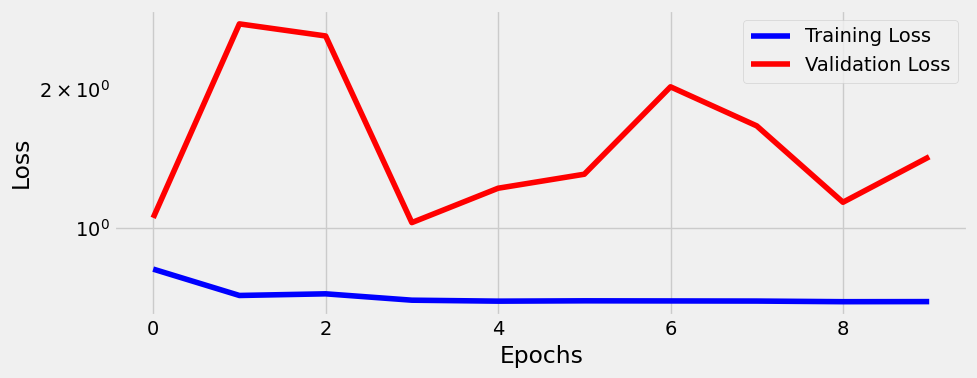

In [6]:
fig = tainer.plot_losses()